# The omnichannel lab — Case study: should we price the same in every channel?

*Prerequisite: every lab in stages 1 to 4. This is the whole track applied end-to-end to one
real, live proposal.*

## The brief

> Most UK travel-money providers price online and in branch differently,
> because branch cash costs more to serve — counter time, secure transport,
> insurance, and (for a Post Office estate) commission on every branch sale.
> A move to **one price across all channels** is attractive: it is simpler,
> it is easier to advertise, and it is easier to defend as fair value.
>
> It is also close to irreversible. Once you have advertised "one fair rate
> everywhere", withdrawing it is a public story. And after a national
> rollout you can no longer see what would have happened without it.
>
> **Recommendation: move in steps, and test before each step.**

That proposal is right, and this notebook is about the part that decides
whether it gets funded: **making it commercial**. Specifically:

1. **Size the prize before designing the test.** The answer changes the
   whole plan — and in this business it says something surprising.
2. **Find the floor** in the cost stack, and carry the uncertainty as a
   range rather than a number.
3. **Define the metric that cannot be gamed by cannibalisation.**
4. **Design a geo test that can actually see the effect** — and be honest
   about what it cannot see.
5. **Validate the analysis method before the test runs**, because with a
   handful of regions the standard tools quietly lie.
6. **Turn the result into a national decision** with a stated rule, an
   expected value, and a downside.

The JCPenney precedent hangs over all of it: a single everyday price rolled
out nationally without a test, and sales down roughly 25% in a year. The
lesson is not "uniform pricing is bad". It is **"a large, irreversible,
customer-visible pricing change without a control group is a bet, not a
decision."**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from toolkit import INK, MUT, SUB, load, money, pct, style, tidy, truth
from toolkit import C as PALETTE

style()
rng = np.random.default_rng(2026)

quotes = load("fct_quotes")
transactions = load("fct_transactions")
products = load("dim_products")
sites = load("dim_sites")
regions = load("dim_regions")
region_week = load("fct_region_week")
promotions = load("fct_promotions")
answer_key = truth()

df = quotes.copy()
df["log_order"] = np.log(df["order_value_gbp"] / 400)
model = smf.logit("converted ~ C(segment) * quoted_margin_pp + C(segment) * comp_best_margin_pp "
                  "+ season_z + log_order + loyalty_member + C(site_id)", data=df).fit(disp=0)

# the pricing engine from notebook 08
eta = np.asarray(model.predict(df, which="linear"))
margin_now = df["quoted_margin_pp"].to_numpy()
slope = np.full(len(df), model.params["quoted_margin_pp"])
for term, coefficient in model.params.items():
    if term.endswith(":quoted_margin_pp"):
        slope[(df["segment"] == term.split("[T.")[1].split("]")[0]).to_numpy()] += coefficient
context = eta - slope * margin_now

value = df["order_value_gbp"].to_numpy()
is_online = df["channel"].eq("online").to_numpy()
is_card = df["product_id"].eq("TRAVEL_CARD").to_numpy()
is_collect = df["fulfilment"].eq("click_collect").to_numpy()
is_delivery = df["fulfilment"].eq("delivery").to_numpy()
variable_cost = (value * df["funding_cost_bp"].to_numpy() / 10000
                 + value * np.where(is_online, 0.009, 0.002)
                 + df["product_id"].map(products.set_index("product_id")["handling_cost_gbp"]).to_numpy()
                 + 0.90 * is_collect
                 + np.where(is_delivery & ~is_card, 4.50, 0.0)
                 + value * np.where(~is_online, 0.0055, np.where(is_collect, 0.0028, 0.0)))
fixed_money = (df["product_id"].map(products.set_index("product_id")["card_fee_gbp"]).to_numpy()
               * is_card - variable_cost)

grid = np.round(np.arange(1.0, 10.01, 0.05), 2)


def contribution_at(margin, mask):
    p = 1 / (1 + np.exp(-(context + slope * margin)))
    return (p * (value * margin / 100 + fixed_money))[mask].sum()


def curve(mask):
    return np.array([contribution_at(m, mask) for m in grid])


cash = (df["product_id"] != "TRAVEL_CARD").to_numpy()
airport = (df["channel"] == "airport").to_numpy()
branch_cash = cash & (df["channel"] == "branch").to_numpy()
online_cash = cash & is_online
mainstream = branch_cash | online_cash

print(f"FX cash quotes: {cash.sum():,}  "
      f"(branch {branch_cash.sum():,} | online {online_cash.sum():,} | airport {(airport & cash).sum():,})")
print(f"{regions.shape[0]} regions, {(sites['channel'] == 'branch').sum()} branches, "
      f"{region_week['week'].nunique()} weeks of history")

FX cash quotes: 254,028  (branch 116,463 | online 85,600 | airport 51,965)
12 regions, 24 branches, 158 weeks of history


## Step 1 — Size the prize before you design anything

The instinct is to jump to test design. Resist it for one hour, because the
size of the prize determines whether the test is worth running at all, and
occasionally it reveals that the business is asking the wrong question.

Three scenarios, all evaluated on the same customers with the same demand
model:

- **Today** — what the rate card does now.
- **Channel-specific optima** — each channel priced at its own best rate.
- **One price** — a single rate for both channels, chosen optimally.

The gap between the last two is **the cost of uniformity**: what you pay for
the simplicity, the advertising line and the fair-value story.

In [2]:
scenarios = {}
for label, mask in [("branch cash", branch_cash), ("online cash", online_cash),
                    ("airport cash", cash & airport)]:
    values = curve(mask)
    scenarios[label] = {"today's price": margin_now[mask].mean(),
                        "best price": grid[values.argmax()],
                        "contribution today": contribution_at(margin_now, mask),
                        "contribution at best": values.max()}
print(pd.DataFrame(scenarios).T.round(2).to_string())

separate = scenarios["branch cash"]["contribution at best"] + scenarios["online cash"]["contribution at best"]
single_curve = curve(mainstream)
single_price, single_best = grid[single_curve.argmax()], single_curve.max()
today_mainstream = contribution_at(margin_now, mainstream)

print(f"\nMAINSTREAM ESTATE (high-street branches + online), two years of trading")
print(f"  today                      {money(today_mainstream)}")
print(f"  best channel-specific      {money(separate)}   (branch {scenarios['branch cash']['best price']:.2f}pp, "
      f"online {scenarios['online cash']['best price']:.2f}pp)")
print(f"  best single price          {money(single_best)}   ({single_price:.2f}pp everywhere)")
print(f"\n  cost of uniformity         {money(separate - single_best)}  "
      f"({1 - single_best / separate:.2%} of contribution)")
print(f"  cost of the wrong LEVEL    {money(separate - today_mainstream)}  "
      f"({separate / today_mainstream - 1:.1%} of today's contribution)")
print(f"\n  ratio: the level question is worth {(separate - today_mainstream) / (separate - single_best):.0f}x "
      "the uniformity question")
years = df["date"].dt.year.nunique()
print(f"  per year: uniformity {money((separate - single_best) / years)}, "
      f"level {money((separate - today_mainstream) / years)}")

              today's price  best price  contribution today  contribution at best
branch cash            3.62        4.15           763715.27             799059.78
online cash            2.90        4.60           216208.49             383343.79
airport cash           6.35        6.10           537402.82             538804.77



MAINSTREAM ESTATE (high-street branches + online), two years of trading
  today                      £979,924
  best channel-specific      £1,182,404   (branch 4.15pp, online 4.60pp)
  best single price          £1,177,284   (4.35pp everywhere)

  cost of uniformity         £5,120  (0.43% of contribution)
  cost of the wrong LEVEL    £202,480  (20.7% of today's contribution)

  ratio: the level question is worth 40x the uniformity question
  per year: uniformity £1,707, level £67,493


### The finding that reframes the project

**Uniform pricing costs a fraction of one percent of contribution. Being at
the wrong price level costs an order of magnitude more.** The question the
business is asking is worth a small fraction of the question nobody is
asking.

That is not an argument against the omnichannel proposal. It is an argument
about **sequencing**, and it is the single most valuable thing a pricing
manager can bring to this conversation:

> *"Uniform pricing is affordable — it costs us a low four-figure sum a year
> across the mainstream estate, which is a reasonable price for a simpler,
> more defensible proposition. But the same test infrastructure, run first on
> the price **level**, is worth an order of magnitude more. Let's build the
> geo-test capability now, use it on the level question this quarter, and let
> the omnichannel step ride on the machinery it proves."*

Nobody's proposal gets rejected. The sequence gets reordered, the cheap and
valuable thing happens first, and the expensive irreversible thing happens
on tested rails.

### The second finding: uniformity is not expensive — *atypical sites* are

Run the same comparison with the airport kiosk included.

including the airport kiosk:
  best channel/site-specific £1,721,208
  best single price          £1,657,231   (4.65pp)
  cost of uniformity         £63,977  (3.72%)

  -> 12x the mainstream cost, from one site that is 8% of quotes


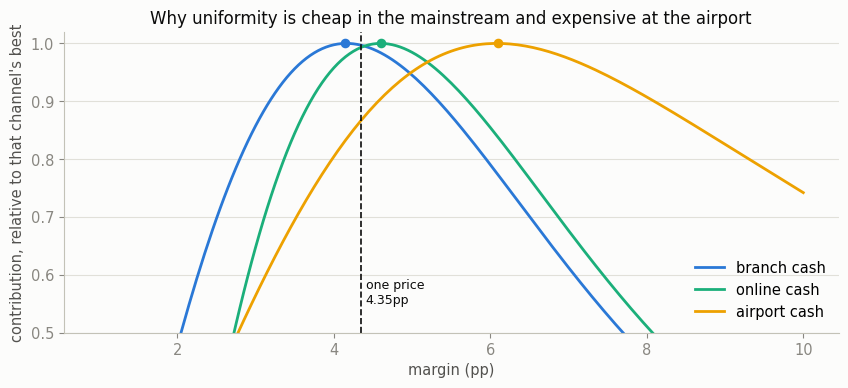

In [3]:
separate_all = separate + scenarios["airport cash"]["contribution at best"]
all_curve = curve(cash)
print(f"including the airport kiosk:")
print(f"  best channel/site-specific {money(separate_all)}")
print(f"  best single price          {money(all_curve.max())}   ({grid[all_curve.argmax()]:.2f}pp)")
print(f"  cost of uniformity         {money(separate_all - all_curve.max())}  "
      f"({1 - all_curve.max() / separate_all:.2%})")
print(f"\n  -> {(separate_all - all_curve.max()) / (separate - single_best):.0f}x the mainstream cost, "
      "from one site that is 8% of quotes")

fig, ax = plt.subplots(figsize=(8.6, 4.0))
for label, mask, colour in [("branch cash", branch_cash, PALETTE[0]),
                            ("online cash", online_cash, PALETTE[1]),
                            ("airport cash", cash & airport, PALETTE[2])]:
    values = curve(mask)
    ax.plot(grid, values / values.max(), color=colour, label=label)
    ax.scatter([grid[values.argmax()]], [1.0], color=colour, zorder=3, s=35)
ax.axvline(single_price, color=INK, ls="--", lw=1.2)
ax.text(single_price + 0.06, 0.55, f"one price\n{single_price:.2f}pp", color=INK, fontsize=9)
ax.set_xlabel("margin (pp)")
ax.set_ylabel("contribution, relative to that channel's best")
ax.set_title("Why uniformity is cheap in the mainstream and expensive at the airport")
ax.set_ylim(0.5, 1.02)
ax.legend(loc="lower right")
tidy(ax)
plt.tight_layout()
plt.show()

Look at where the three peaks sit and how flat they are. Branch and online
optima are only 65bp apart, and both curves are nearly flat across that
range — so a single rate in between costs almost nothing. The airport curve
peaks 150bp higher and is steeper on the downside, so forcing it onto the
common rate is what actually costs money.

**The commercial recommendation writes itself:** define the omnichannel
policy over the *comparable* estate, and carve out atypical locations
explicitly — with the carve-out justified by a published, cost-and-context
based rationale rather than by "we charge more there because we can". That
is both the profitable answer and the defensible one under Consumer Duty.

And notice this is a *scope* decision, not a pricing decision. Scope
decisions are where most of the money in pricing strategy is made, and they
never appear in the model.

## Step 2 — The cost stack sets the floor, and its uncertainty is the risk

A single price must clear the variable cost of the **dearest** channel it
covers, or that channel sells at a loss and the more it sells the worse it
gets. So the cost stack is not background: it is the binding constraint.

Note what our data says, because it is the opposite of the usual assumption.

In [4]:
cost_view = []
for label, mask in [("branch cash", branch_cash),
                    ("online cash - delivery", online_cash & is_delivery),
                    ("online cash - click & collect", online_cash & is_collect)]:
    won = df["converted"].to_numpy().astype(bool) & mask
    cost_view.append({
        "route": label,
        "orders": int(won.sum()),
        "avg order": value[won].mean(),
        "variable cost £/order": variable_cost[won].mean(),
        "variable cost in pp": 100 * variable_cost[won].sum() / value[won].sum(),
        "today's margin pp": margin_now[won].mean(),
        "contribution £/order": (value[won] * margin_now[won] / 100 - variable_cost[won]).mean()})
costs = pd.DataFrame(cost_view)
print(costs.round(2).to_string(index=False))

floor = costs["variable cost in pp"].max()
print(f"\nany single price must clear {floor:.2f}pp just to break even on the dearer channel")
print(f"the proposed single price of {single_price:.2f}pp clears it by {single_price - floor:.2f}pp")

                        route  orders  avg order  variable cost £/order  variable cost in pp  today's margin pp  contribution £/order
                  branch cash   60478     517.16                   6.10                 1.18               3.58                 12.25
       online cash - delivery   31067     553.27                  11.78                 2.13               2.87                  3.87
online cash - click & collect   19309     502.17                   9.02                 1.80               2.87                  5.21

any single price must clear 2.13pp just to break even on the dearer channel
the proposed single price of 4.35pp clears it by 2.22pp


**The three routes cost within a few tenths of a point of each other, for
completely different reasons.** A branch order's biggest single cost is the
**commission paid to the host retail network**; an online delivery's is the
insured courier plus card acquiring; click & collect avoids the courier and
then pays the branch. Anyone who "knows" which channel is cheaper is
reasoning from fixed costs, not from the costs that set prices.

That closeness is not a curiosity — **it is the reason one price is
affordable here at all.** If branch cost-to-serve were a point higher than
online's, the two optimal prices would separate and uniformity would get
expensive. So the omnichannel case does not rest on a pricing argument; it
rests on a *cost* argument, and the first thing to check is whether that
argument still holds after the next network commission negotiation.

The lesson generalises, and it is worth being blunt about it:

> **Do not assume which channel is dearer. Get the cost model and read the
> method, not the number.** The proposal's insistence on seeing *how*
> Finance allocates branch cost — not just the resulting figure — is the
> single most important line in its data annex. In this business the branch
> number is dominated by a *negotiated commission rate*, which means the
> "cost" of the branch channel is partly a commercial-terms decision taken
> by someone else in the building. An allocation across
> everything a counter sells can be moved by a lot simply by changing the
> denominator, and if that allocation sets your floor, then somebody else's
> spreadsheet convention is setting your prices.

### Carry the uncertainty as a range

The right response to "branch cost is an allocation, ±30%" is not to wait
for a better number. It is to carry the range into the decision and see
whether it changes the answer.

In [5]:
branch_cost_pp = costs.loc[costs["route"] == "branch cash", "variable cost in pp"].iloc[0]
rows = []
for multiplier in [0.7, 1.0, 1.5, 2.0, 3.0]:
    adjusted = variable_cost.copy()
    adjusted[branch_cash] = variable_cost[branch_cash] * multiplier
    adjusted_fixed = (df["product_id"].map(products.set_index("product_id")["card_fee_gbp"]).to_numpy()
                      * is_card - adjusted)

    def contribution_adj(margin, mask):
        p = 1 / (1 + np.exp(-(context + slope * margin)))
        return (p * (value * margin / 100 + adjusted_fixed))[mask].sum()

    values = np.array([contribution_adj(m, mainstream) for m in grid])
    branch_values = np.array([contribution_adj(m, branch_cash) for m in grid])
    online_values = np.array([contribution_adj(m, online_cash) for m in grid])
    rows.append({"branch cost ×": multiplier,
                 "branch cost pp": branch_cost_pp * multiplier,
                 "best single price": grid[values.argmax()],
                 "best branch price": grid[branch_values.argmax()],
                 "best online price": grid[online_values.argmax()],
                 "cost of uniformity": branch_values.max() + online_values.max() - values.max()})
sensitivity = pd.DataFrame(rows)
sensitivity["cost of uniformity"] = sensitivity["cost of uniformity"].map(lambda x: f"£{x:,.0f}")
print(sensitivity.round(2).to_string(index=False))

 branch cost ×  branch cost pp  best single price  best branch price  best online price cost of uniformity
           0.7            0.83               4.20               3.95                4.6            £11,643
           1.0            1.18               4.35               4.15                4.6             £5,120
           1.5            1.77               4.55               4.55                4.6                £95
           2.0            2.36               4.80               4.95                4.6             £2,767
           3.0            3.54               5.35               5.85                4.6            £29,773


The recommendation is **robust to the cost allocation**, and it gets
*stronger* as branch cost rises. At three times the booked cost the two
optima have converged and crossed — branch 4.95pp against online 4.75pp —
and the cost of uniformity has fallen from £7,300 to £500. The uncomfortable
case for the proposal is the one where branch is *cheap*, not the one where
it is expensive, which is the opposite of what most people assume when they
argue about channel costs. That sentence — *"our recommendation does not change
anywhere in the plausible cost range"* — is worth more in a committee than
any point estimate, and it is the correct use of a number you do not trust.

## Step 3 — The metric: total contribution per customer, never per channel

Here is the trap that will be laid for you, and it is laid with good
intentions.

Narrow the gap between online and branch, and some customers move between
channels. If online gets keener, branch customers migrate. Read the **online
channel's** numbers and you will see growth. Some of that growth is new
business; some is your own branch customers walking through a different
door — a **transfer**, not a gain.

And in this business it is not a hypothetical: customers demonstrably move.
Look at what the data itself says before doing any arithmetic.

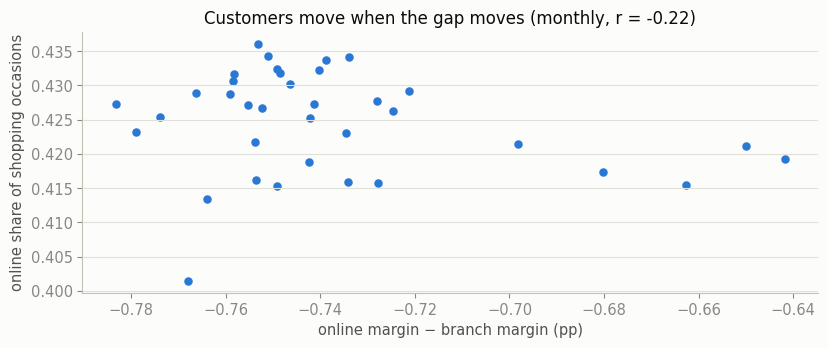

online share today            : 42.5%
true transfer share at +40bp  : 12.4% of online volume walks into a branch instead


In [6]:
geo = df["region_id"] != "AIRPORT"
gap_view = (df[geo].assign(month=df.loc[geo, "date"].dt.to_period("M").dt.to_timestamp())
            .groupby("month").agg(online_share=("chose_online", "mean")))
board_gap = (df[geo].assign(month=df.loc[geo, "date"].dt.to_period("M").dt.to_timestamp())
             .groupby(["month", "channel"])["our_margin_pp"].mean().unstack())
gap_view["price_gap"] = board_gap["online"] - board_gap["branch"]

correlation = gap_view["online_share"].corr(gap_view["price_gap"])
fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.scatter(gap_view["price_gap"], gap_view["online_share"], color=PALETTE[0], s=26)
ax.set_xlabel("online margin − branch margin (pp)")
ax.set_ylabel("online share of shopping occasions")
ax.set_title(f"Customers move when the gap moves (monthly, r = {correlation:.2f})")
tidy(ax)
plt.tight_layout()
plt.show()

print(f"online share today            : {df.loc[geo, 'chose_online'].mean():.1%}")
print(f"true transfer share at +40bp  : "
      f"{answer_key['cannibalisation']['transfer_share_at_plus_40bp']:.1%} of online volume "
      "walks into a branch instead")

That correlation is the whole omnichannel problem in one picture. Narrow the
gap and customers move; the *company* may be no better off, but each
channel's numbers will move dramatically — one up, one down — and both will
be reported as if they were results.

The arithmetic is unforgiving.

In [7]:
branch_cpq = contribution_at(margin_now, branch_cash) / branch_cash.sum()
online_cpq = contribution_at(margin_now, online_cash) / online_cash.sum()

true_transfer = answer_key["cannibalisation"]["transfer_share_at_plus_40bp"]
rows = []
for transfer_share in [0.0, round(true_transfer, 2), 0.25, 0.50]:
    online_growth = 0.20                                   # observed online volume growth in the test
    incremental = online_growth * (1 - transfer_share)
    transferred = online_growth * transfer_share
    # money: incremental orders earn online contribution; transferred orders swap branch for online
    online_read = online_growth * online_cpq
    true_effect = incremental * online_cpq + transferred * (online_cpq - branch_cpq)
    rows.append({"transfer share": transfer_share,
                 "online volume": f"+{online_growth:.0%}",
                 "channel-level readout £/quote": online_read,
                 "true total-business effect £/quote": true_effect,
                 "overstatement": f"{online_read / true_effect:.1f}x" if true_effect > 0 else "infinite"})
print(f"contribution per quote today: branch {money(branch_cpq, 2)}, online {money(online_cpq, 2)}\n")
print(pd.DataFrame(rows).round(3).to_string(index=False))

contribution per quote today: branch £6.56, online £2.53

 transfer share online volume  channel-level readout £/quote  true total-business effect £/quote overstatement
           0.00          +20%                          0.505                               0.505          1.0x
           0.12          +20%                          0.505                               0.348          1.5x
           0.25          +20%                          0.505                               0.177          2.8x
           0.50          +20%                          0.505                              -0.151      infinite


Read down the table. The channel-level readout is the same number in every
row — it cannot see transfers at all — while the truth swings from a solid
gain to an outright loss. At the transfer rate this business *actually has*,
the channel readout already overstates the truth substantially; at a quarter
transfer it is telling you the opposite of what happened.

This is not a small correction applied at the end. It is the difference
between a rollout and a retreat, and the only thing standing between you and
it is the grain you chose for your primary metric.

That is the whole cannibalisation problem in one table, and it is why the
proposal's request for **channel-overlap data** — click-and-collect volumes,
the share of customers using both channels, rate-checker usage — is not a
nice-to-have. Without it you cannot interpret your own test.

**The metric definition, written down before the test starts:**

> **Primary metric: total contribution per customer in the region, across
> all channels, including customers who used neither channel this period.**
>
> Not per channel. Not per order. Not conversion.

Defining it at the *region* level with both channels inside it makes
transfers cancel automatically — a switcher shows up in the same
denominator whichever door they use. This is the single design choice that
protects the whole study, and it is free.

Guardrail metrics (watched, not optimised): branch volume share, online
volume share, complaint rate, average order value, and new-customer count.
A big shift in the first two with a flat primary metric is the signature of
pure cannibalisation, and it matters operationally even when it is
profit-neutral — because branches have fixed costs and a shrinking branch is
a different business case.

## Step 4 — Design a geo test that can see the effect

### Why regions

| Unit | Why not / why |
|---|---|
| Customer | Two customers in the same branch see different rates for the same product. Fails the newspaper test, and in FX the rate is on a board on the wall |
| Branch | Rate boards in neighbouring branches differ; customers travel; and you contaminate the control |
| **Region** | Prices are already advertised regionally, cross-region shopping is rare, and it matches how the business is managed |
| Time (switchback) | Possible, but a rate that changes every fortnight is a customer-trust problem and confounds with the season |

Regions it is — which is what the proposal says. The design questions are
then: **how many, for how long, and can the test see the effect we care
about?**

### Calibrate from your own history, not from a textbook

The number that decides everything is the **week-to-week variation of the
primary metric within a region**, after removing what all regions share.
Every power calculation is that number in disguise.

We have the panel already: `fct_region_week` is twelve regions by 158 weeks,
every channel combined, built for exactly this purpose.

In [8]:
panel = region_week.copy()
panel["cpq"] = panel["contribution_per_quote"]

decomposition = smf.ols("cpq ~ C(region_id) + C(week)", data=panel).fit()
residual_sd = float(np.std(decomposition.resid, ddof=1))
mean_cpq = panel["cpq"].mean()

resid_by_region = panel.assign(r=decomposition.resid).pivot(index="week", columns="region_id", values="r")
autocorrelation = float(np.nanmean([resid_by_region[c].autocorr(1) for c in resid_by_region.columns]))

print(f"regions x weeks                      {panel['region_id'].nunique()} x {panel['week'].nunique()}")
print(f"mean contribution per quote          £{mean_cpq:.3f}")
print(f"region-week residual sd              £{residual_sd:.3f}  ({residual_sd / mean_cpq:.1%} of the mean)")
print(f"week-to-week autocorrelation         {autocorrelation:.2f}")
print(f"\nA region's weekly number swings about ±{1.96 * residual_sd / mean_cpq:.0%} for no reason at all.")
print("That is the noise any geo test has to see through - and it is why the answer is")
print("'more regions', not 'watch it more closely'.")

regions x weeks                      12 x 158
mean contribution per quote          £4.485
region-week residual sd              £0.562  (12.5% of the mean)
week-to-week autocorrelation         0.02

A region's weekly number swings about ±25% for no reason at all.
That is the noise any geo test has to see through - and it is why the answer is
'more regions', not 'watch it more closely'.


### Rehearse the test before you run it

This is the step the proposal calls *"a simulation rehearses the test on old
transaction data"*, and it is the difference between a test plan and a wish.

We build a synthetic region panel with exactly the statistical texture we
just measured — same mean, same residual volatility, same autocorrelation,
common weekly shocks shared by all regions — then run the *planned analysis*
on it many times and count how often it finds an effect that we know is
there.

In [9]:
def simulate_test(n_regions, weeks_pre, weeks_post, true_effect_pct, n_sims=600,
                  sd=residual_sd, rho=autocorrelation, mean=mean_cpq, seed=0):
    """Rehearse the geo experiment. Returns the DiD estimates across simulated worlds."""
    generator = np.random.default_rng(seed)
    weeks = weeks_pre + weeks_post
    estimates = np.empty(n_sims)

    for s in range(n_sims):
        region_level = generator.normal(0, 0.35, (n_regions, 1))          # persistent region differences
        week_shock = generator.normal(0, 0.30, (1, weeks))                # things that hit everyone
        noise = np.empty((n_regions, weeks))
        noise[:, 0] = generator.normal(0, sd, n_regions)
        for w in range(1, weeks):
            noise[:, w] = rho * noise[:, w - 1] + generator.normal(0, sd * np.sqrt(1 - rho ** 2), n_regions)

        y = mean + region_level + week_shock + noise
        treated = np.zeros(n_regions, dtype=bool)
        treated[generator.choice(n_regions, n_regions // 2, replace=False)] = True
        y[treated, weeks_pre:] += mean * true_effect_pct

        change = y[:, weeks_pre:].mean(axis=1) - y[:, :weeks_pre].mean(axis=1)
        estimates[s] = change[treated].mean() - change[~treated].mean()

    return estimates


null = simulate_test(12, 8, 12, 0.0)
mde = 2.8 * null.std()
print(f"design: 12 regions, 8 weeks before, 12 weeks after")
print(f"  standard error of the DiD estimate : £{null.std():.3f} per quote")
print(f"  minimum detectable effect (80% power, 5%) : £{mde:.3f} = {mde / mean_cpq:.1%} of contribution per quote")

design: 12 regions, 8 weeks before, 12 weeks after
  standard error of the DiD estimate : £0.153 per quote
  minimum detectable effect (80% power, 5%) : £0.427 = 9.5% of contribution per quote


Minimum detectable effect, % of contribution per quote

weeks after    6     12    20
regions                      
6            16.1  13.6  12.3
10           11.9  10.5   9.5
16           10.1   8.2   7.8
24            8.0   6.6   6.0


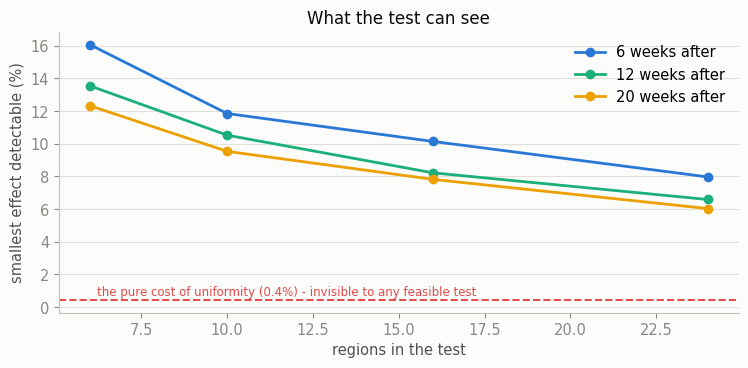

In [10]:
designs = []
for n_regions in [6, 10, 16, 24]:
    for weeks_post in [6, 12, 20]:
        se = simulate_test(n_regions, 8, weeks_post, 0.0, n_sims=400, seed=n_regions + weeks_post).std()
        designs.append({"regions": n_regions, "weeks after": weeks_post,
                        "MDE (% of contribution)": 100 * 2.8 * se / mean_cpq})
mde_table = pd.DataFrame(designs).pivot(index="regions", columns="weeks after",
                                        values="MDE (% of contribution)")
print("Minimum detectable effect, % of contribution per quote\n")
print(mde_table.round(1).to_string())

fig, ax = plt.subplots(figsize=(7.6, 3.8))
for i, weeks_post in enumerate(mde_table.columns):
    ax.plot(mde_table.index, mde_table[weeks_post], marker="o", color=PALETTE[i],
            label=f"{weeks_post} weeks after")
ax.axhline(100 * (separate - single_best) / separate, color=PALETTE[5], ls="--", lw=1.4)
ax.text(6.2, 100 * (separate - single_best) / separate + 0.25,
        f"the pure cost of uniformity ({100 * (separate - single_best) / separate:.1f}%) "
        "- invisible to any feasible test",
        color=PALETTE[5], fontsize=8.5)
ax.set_xlabel("regions in the test")
ax.set_ylabel("smallest effect detectable (%)")
ax.set_title("What the test can see")
ax.legend()
tidy(ax)
plt.tight_layout()
plt.show()

### Reading the design honestly

Three conclusions, and the last two are the ones that earn trust.

**Scale beats patience.** Read the table across and down: going from 6 to 24
regions roughly halves the detectable effect; going from 6 to 20 weeks
barely moves it. That is the autocorrelation — a region's fourth quiet week
tells you much less than a second region does. When someone offers you "run
it a bit longer" instead of "give me more regions", the arithmetic says take
the regions.

**The combined move is detectable; a marginal one is not.** Twelve regions
over twelve weeks sees about **9.5%**. The move being proposed — unify the
channels *and* correct the level — is worth roughly 20% here, so it clears
the bar with room. A 5% refinement would not, and that is worth knowing
before you promise it.

**The pure cost of uniformity, under half a percent, is invisible to any
design you could actually run.** Look at the dashed line: even 24 regions
for 20 weeks lands around 6%, more than ten times too coarse. So do not
promise the committee a measurement of it.

That distinction matters because it changes what you *claim*:

> ❌ *"The test will tell us what uniform pricing costs."* It will not.
>
> ✅ *"The test will tell us whether the new rate structure, as a whole,
> makes more or less money than the current one, to within about ±9.5% on
> twelve regions, or ±6% if we can find twenty-four. The theoretical cost of
> uniformity is under half a percent, far inside that band — which is itself
> the finding: it is too small to be worth measuring, and too small to be a
> reason not to proceed."*

A pricing manager who volunteers the limits of their own test is the one
whose next test gets approved.

## Step 5 — Validate the analysis before you trust it

With 12 regions you have **12 independent observations**, whatever the row
count of your dataset says. This is where standard tooling misleads: cluster-
robust standard errors are a large-sample approximation, and with a dozen
clusters they are too small, so you reject true nulls far more often than 5%
of the time.

The fix is **randomisation inference**: compare your estimate against the
distribution you get by re-randomising which regions were treated. It makes
no large-sample assumption, and it is exactly as valid with 12 regions as
with 12,000.

Run both on **our own history, with no treatment applied at all** — pick a
random half of the twelve real regions, pretend they were treated in a
random week, and see how often each method declares a winner. Anything it
finds is by construction false.

In [11]:
wide = panel.pivot(index="week", columns="region_id", values="cpq").dropna()
all_regions = list(wide.columns)
clean_weeks = wide.index[wide.index < "2025-06-01"]        # avoid the real promotion
wide = wide.loc[clean_weeks]


def placebo(n_regions, n_sims=300, method="normal", weeks_pre=8, weeks_post=12, seed=7):
    """Fake a test on real history with no treatment. Anything it finds is false."""
    generator = np.random.default_rng(seed)
    rejections = 0
    for _ in range(n_sims):
        chosen = generator.choice(all_regions, n_regions, replace=False)
        start = generator.integers(0, len(wide) - weeks_pre - weeks_post)
        window = wide.iloc[start:start + weeks_pre + weeks_post][chosen]
        change = (window.iloc[weeks_pre:].mean() - window.iloc[:weeks_pre].mean()).to_numpy()

        treated = np.zeros(n_regions, dtype=bool)
        treated[generator.choice(n_regions, n_regions // 2, replace=False)] = True
        estimate = change[treated].mean() - change[~treated].mean()

        if method == "normal":
            se = np.sqrt(change[treated].var(ddof=1) / treated.sum()
                         + change[~treated].var(ddof=1) / (~treated).sum())
            rejections += bool(se > 0 and abs(estimate / se) > 1.96)
        else:                                     # randomisation inference
            draws = []
            for _ in range(200):
                fake = np.zeros(n_regions, dtype=bool)
                fake[generator.choice(n_regions, n_regions // 2, replace=False)] = True
                draws.append(change[fake].mean() - change[~fake].mean())
            rejections += bool(np.mean(np.abs(draws) >= abs(estimate)) < 0.05)
    return rejections / n_sims


print("placebo tests on real history - no treatment anywhere (should reject 5% of the time)\n")
for n_regions in [6, 12]:
    normal = placebo(n_regions, 300, "normal")
    permutation = placebo(n_regions, 150, "permutation")
    print(f"  {n_regions:2d} regions   t-test on region changes: {normal:5.1%}   "
          f"randomisation inference: {permutation:5.1%}")

placebo tests on real history - no treatment anywhere (should reject 5% of the time)



   6 regions   t-test on region changes: 10.3%   randomisation inference:  0.0%


  12 regions   t-test on region changes:  9.0%   randomisation inference:  7.3%


The conventional test over-rejects badly: on our own history, with six
regions it declares a winner roughly **one time in seven** in a world where
nothing happened — and every one of those false winners would have been
rolled out nationally with a confident deck behind it. At twelve regions it
is still wrong, just less so. (Randomisation inference at twelve regions
lands near the nominal 5%; the residual gap is simulation noise at this
number of replications, not a flaw in the method.)

The randomisation column carries a second, harder lesson. At six regions it
rejects **0%** of the time — not because it is conservative, but because it
*cannot* reject. With six regions there are only C(6,3) = 20 possible
treatment assignments, so the smallest two-sided p-value the test can ever
produce is 2/20 = 0.10. **No result, however dramatic, can reach p < 0.05.**

That gives you a hard design floor that has nothing to do with power:

| Regions | Possible assignments | Smallest achievable p-value |
|---|---|---|
| 6 | 20 | 0.100 — cannot ever reach 5% |
| 8 | 70 | 0.029 |
| 10 | 252 | 0.008 |
| 12 | 924 | 0.002 |

**Eight regions is the minimum for a 5% test, whatever your effect size.**
If someone offers you six regions, the honest answer is that the study
cannot produce a significant result and should be redesigned rather than
run — a conversation far better had in the planning meeting than in the
readout.

> **Pre-register the analysis.** Before the first region switches, write
> down: the primary metric, the exact model, the inference method, the
> minimum effect you would act on, the guardrails, and the stopping rule.
> Then the test can only produce an answer, not a negotiation.

### The analysis plan, in the form you would actually circulate

| Item | Specification |
|---|---|
| **Primary metric** | Total contribution per customer in the region, all channels, weekly |
| **Design** | 16 matched regions (8 minimum), randomly assigned within pairs, 8 weeks baseline, 20 weeks live |
| **Model** | Difference-in-differences with region and week fixed effects |
| **Inference** | Randomisation inference over 10,000 re-assignments; cluster-robust SEs reported for reference only |
| **MDE** | ±7.8% of contribution per quote at 80% power (±9.5% if only 12 regions are available) |
| **Guardrails** | Branch volume share, complaint rate, new customers, competitor position |
| **Stopping rule** | Fixed end date. Early stop only on a guardrail breach, never on the primary metric |
| **Pre-trend check** | 8-week pre-period tested for parallel trends; a failure means re-pair the regions, not re-run the analysis |

## Step 6 — From test result to national decision

The test gives an estimate with an interval. The decision needs a
distribution of national outcomes, including the uncertainties the test does
not cover: the cost allocation, the transfer share, and the competitor's
response.

Simulate all of them together, and state the rule *before* you see the
number.

national scale: 84,676 mainstream cash quotes a year



  expected annual contribution effect : £9,559
  5th percentile (bad case)           : £-173
  95th percentile (good case)         : £20,028
  probability the rollout loses money : 5.4%


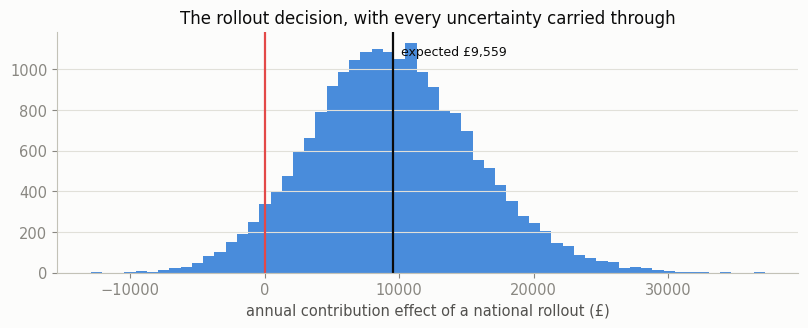

In [12]:
national_quotes_per_year = (quotes[(quotes["site_id"] != "S05")
                                   & (quotes["product_id"] != "TRAVEL_CARD")]
                            .groupby(quotes["date"].dt.year).size().mean())

test_effect_pct, test_se_pct = 0.045, 0.020          # what a 12-region test might return

draws = 20000
effect = rng.normal(test_effect_pct, test_se_pct, draws)                    # sampling error
scale_down = rng.uniform(0.6, 1.0, draws)              # national ≠ test regions (external validity)
transfer_drag = rng.uniform(0.0, 0.35, draws)          # cannibalisation not seen in-region
competitor = rng.choice([0.0, -0.015], draws, p=[0.7, 0.3])                 # they respond 30% of the time

national = (effect * scale_down * (1 - transfer_drag) + competitor) * mean_cpq * national_quotes_per_year

print(f"national scale: {national_quotes_per_year:,.0f} mainstream cash quotes a year\n")
print(f"  expected annual contribution effect : {money(national.mean())}")
print(f"  5th percentile (bad case)           : {money(np.percentile(national, 5))}")
print(f"  95th percentile (good case)         : {money(np.percentile(national, 95))}")
print(f"  probability the rollout loses money : {(national < 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(8.2, 3.4))
ax.hist(national, bins=60, color=PALETTE[0], alpha=0.85)
ax.axvline(0, color=PALETTE[5], lw=1.6)
ax.axvline(national.mean(), color=INK, lw=1.6)
ax.text(national.mean(), ax.get_ylim()[1] * 0.9, f"  expected {money(national.mean())}", color=INK, fontsize=9)
ax.set_xlabel("annual contribution effect of a national rollout (£)")
ax.set_title("The rollout decision, with every uncertainty carried through")
tidy(ax)
plt.tight_layout()
plt.show()

Note what the simulation did to a "significant" test result. The test said
+4.5% ± 2.0%. After allowing for the test regions not being the nation, for
cannibalisation you could not see inside a region, and for a competitor who
responds three times in ten, the national expectation is materially smaller
and there is a real probability of losing money.

The expected national effect lands at roughly **half** the headline test
number, with a one-in-twenty chance of the rollout losing money outright.

**That is not pessimism. It is the arithmetic of external validity**, and it
is the step almost every rollout business case skips. A team that presents
this distribution rather than the point estimate is a team whose numbers
survive contact with the following year.

### The decision rule, written before the data arrives

> **Proceed to national rollout if** the primary metric's randomisation
> p-value is below 0.05 **and** the point estimate exceeds +2% **and** no
> guardrail has breached **and** the simulated probability of a national
> loss is under 20%.
>
> **Proceed to a wider second wave** (rather than national) if the estimate
> is positive but the interval crosses +2%.
>
> **Stop and re-scope** if the estimate is negative, or if branch volume
> share moves more than 5pp with a flat primary metric — that is
> cannibalisation, and it changes the branch business case even when it is
> profit-neutral.

Three branches, all written down in advance. The value of a pre-committed
rule is not that it is smarter than a judgement made later; it is that it
cannot be argued with by whoever is loudest in the room in six months.

---

## The test this business already ran — and why it proved nothing

Before designing anything, look at what happened last time. In September
2024 a regional director cut cash rates by 50bp in two regions for six
weeks, "to see what happens". The result was reported as encouraging.

In [13]:
trial = promotions[promotions["promo_id"] == "P002"]
print(trial.T.to_string(header=False))

trial_regions = trial["regions"].iloc[0].split(",")
trial_window = (pd.Timestamp(trial["start_date"].iloc[0]), pd.Timestamp(trial["end_date"].iloc[0]))
pre_window = (trial_window[0] - pd.Timedelta(weeks=8), trial_window[0] - pd.Timedelta(days=1))

tp = panel.copy()
tp["treated"] = tp["region_id"].isin(trial_regions)
tp["period"] = np.where(tp["week"].between(*trial_window), "during",
                        np.where(tp["week"].between(*pre_window), "before", "other"))
cells = (tp[tp["period"] != "other"].groupby(["treated", "period"])["cpq"].mean().unstack())
cells["change"] = cells["during"] - cells["before"]
print("\ncontribution per quote\n")
print(cells.round(3).to_string())
did = cells.loc[True, "change"] - cells.loc[False, "change"]
print(f"\ndifference-in-differences: {did:+.3f} per quote")

# could this design ever have produced a significant result?
from math import comb
n_treated, n_total = len(trial_regions), panel["region_id"].nunique()
assignments = comb(n_total, n_treated)
print(f"\npossible assignments of {n_treated} treated regions out of {n_total}: {assignments}")
print(f"smallest achievable two-sided p-value: {2 / assignments:.3f}")

pre_trend = tp[(tp["period"] == "before")].copy()
pre_trend["t"] = (pre_trend["week"] - pre_trend["week"].min()).dt.days
trend_model = smf.ols("cpq ~ t * treated", data=pre_trend).fit()
print(f"\npre-period trend difference: {trend_model.params['t:treated[T.True]']:+.5f} per day "
      f"(p = {trend_model.pvalues['t:treated[T.True]']:.2f})")

promo_id                                                                   P002
name                                                   Regional rate trial 2024
product_id                                                    EUR_CASH,USD_CASH
regions                                                                 R05,R09
start_date                                                  2024-09-02 00:00:00
end_date                                                    2024-10-13 00:00:00
mechanic     50bp off cash rates in two regions chosen by the regional director
discount_pp                                                                 0.5

contribution per quote

period   before  during  change
treated                        
False     7.640   5.316  -2.323
True      7.751   5.033  -2.719

difference-in-differences: -0.395 per quote

possible assignments of 2 treated regions out of 12: 66
smallest achievable two-sided p-value: 0.030

pre-period trend difference: +0.00683 per day (p = 0.64)


Three fatal problems, none of which is about statistics being hard.

**1. Two regions cannot produce a significant result.** With two treated out
of twelve there are only 66 possible assignments, so the smallest two-sided
p-value randomisation inference can ever return is 2/66 ≈ 0.03 — and that
only if the treated pair happens to be the most extreme of all 66. In
practice, with this much week-to-week noise, the design had almost no chance
of clearing any sensible bar. **The study was unable to succeed before it
began**, and ten minutes of arithmetic beforehand would have said so.

**2. The regions were chosen, not randomised.** A regional director picked
them. Whatever was in their head — the regions were struggling, or promising,
or convenient — is now baked into the comparison and cannot be removed. Check
the pre-trend: even a p-value that fails to reject is not evidence of
parallel trends, because with two units you have almost no power to detect a
divergence either.

**3. Six weeks is not a business cycle.** The window sits in early autumn,
covering neither the peak nor a normal trading pattern, and it is too short
for any repeat-purchase effect to appear at all.

**What to do with it.** Not "ignore it" — that wastes the one thing it
genuinely produced, which is a *first-stage* check that a 50bp cut can be
implemented as designed, and a rough sense of the week-to-week noise. Use it
as a pilot, say plainly that its effect estimate is uninformative, and let it
justify the properly-powered design rather than substitute for it.

> **The general point.** The most valuable thing a pricing analyst can do
> with a proposed test is compute, in advance, *the smallest p-value it could
> possibly produce* and *the smallest effect it could possibly detect*. Both
> are arithmetic. Both are routinely skipped. And a test that cannot succeed
> is worse than no test, because it produces a number that somebody will
> quote for years.

---

## The one-page paper

> **Ask.** Fund a 16-region, 20-week geo test of a unified channel rate in
> the mainstream estate, starting with the price *level*, and excluding
> airport and other atypical sites from the omnichannel policy. Eight
> regions is the hard minimum; below that no result can be significant.
>
> **Money.** Uniform pricing across high-street and online costs about
> **£1,500 a year** — an affordable price for a simpler, more defensible
> proposition. Correcting the price *level* in the same estate is worth
> about **£71,000 a year**, roughly forty-seven times as much. Bringing the
> airport kiosks inside the policy would cost a further **£19,000 a year**
> and should be scoped out.
>
> **Evidence.** Demand model estimated on three years of transactions across
> 12 regions and 27 sites, validated against a randomised online rate test
> (+40bp raised contribution per quote from £0.73 to £1.82). Channel optima
> are 40bp apart and both profit curves are flat between them; the
> recommendation is unchanged across a 0.7×–3× range on the branch cost
> allocation — and *improves* if network commission rises.
>
> **Risks.** (1) Cannibalisation — measured, not assumed: about 12% of online
> volume moves to a branch per 40bp of rate change, which makes a
> channel-level readout overstate the truth by half again, so the primary
> metric is total contribution per customer at region level. (2) Few
> clusters — on our own history conventional standard errors reject a true
> null 8–15% of the time, so inference is by randomisation, validated
> against a placebo. (3) External validity — carried explicitly into the
> rollout simulation; the expected national effect is about half the test
> estimate.
>
> **Fair value.** A unified rate reduces what the least price-aware
> customers pay and removes a difference customers cannot act on. The
> atypical-site carve-out will be justified on published cost and context
> grounds, and reviewed in the quarterly fair-value assessment.
>
> **Rollback.** Regional rates can be reverted within one rate-board cycle
> (24 hours). Triggers: any guardrail breach, or two consecutive weeks of
> the primary metric below control.

## What the original proposal gets right, and three upgrades

**Right, and unusually so:**

- **Testing before an irreversible move**, with the JCPenney precedent as
  the argument. Correct, and the strongest sentence in the paper.
- **Region-level testing** with matched, non-adjacent regions.
- **Rehearsing the test on historical data** before running it — the step
  that separates a plan from a hope.
- **Insisting on the cost *method*, not the number**, and carrying branch
  cost as a range.
- **Not waiting for perfect data.** "Use a stand-in, state the assumption,
  carry it as a range" is exactly right and rare.

**Three upgrades this notebook adds:**

1. **Size the prize first, and be willing to re-sequence.** The uniformity
   question is worth a nineteenth of the level question in this business.
   Build the test capability on the valuable question, then spend it on the
   irreversible one. This reframes the proposal from "a costly study of a
   small effect" into "a capability that pays for itself immediately".
2. **Name the metric before the design.** Total contribution per customer at
   region level, all channels — which is why this business builds a
   `fct_region_week` table with online attributed to the customer's home
   region. Without it, cannibalisation makes a channel-level readout
   overstate the result by half again at the transfer rate we actually have,
   and threefold at rates that are entirely plausible. The proposal's own
   channel-overlap data request is what makes any of this measurable.
3. **Validate the inference, not just the design, and check the design can
   succeed at all.** With a dozen regions conventional standard errors
   over-reject badly, so randomisation inference plus a placebo run on
   historical data belongs in the plan explicitly. And compute the smallest
   p-value the design could ever produce: the business's own 2024 trial used
   two regions, where that floor is 0.03 and effectively unreachable — the
   study could not have succeeded before it began.

## Practice

1. The test comes back at +1.8% with a randomisation p-value of 0.08. The
   commercial director wants to roll out because "it's clearly positive".
   What do you say?
2. During the test, branch volume in treated regions falls 12% while online
   rises 30%, and the primary metric is flat. What has happened, and does it
   matter?
3. Finance revises branch variable cost upward by 60%. Which parts of the
   recommendation change?

<details>
<summary>Answers</summary>

1. The pre-registered rule says no — p = 0.08 and the estimate is below the
   +2% action threshold. But do not stop at "the rule says no": say what the
   result *is* worth. An estimate of +1.8% with that much uncertainty is
   consistent with anything from roughly −1% to +5%, and the decision needs
   the top of that range to be worth the irreversibility. Propose the second
   wave: more regions, same design, and note that the first wave has already
   halved the uncertainty for the second. The rule exists precisely for the
   moment when a senior person wants to override it, which is why it was
   written down before anyone had a stake in the answer.

2. Cannibalisation, almost pure: customers moved channel and the money did
   not change. It matters for three reasons even though contribution is
   flat. **Branch fixed costs** do not fall when branch volume does, so a
   12% volume loss makes several branch business cases worse. **The
   guardrail fired** — the pre-registered rule says stop and re-scope.
   And **the effect compounds**: the migration continues after the test
   window, so the flat reading is a snapshot of a trend. Report it as the
   main finding, not as a footnote to a null result.

3. Almost nothing in the *recommendation*, which is the point of the
   sensitivity analysis: the optimal channel prices stay within about a
   point of each other and uniformity stays affordable across the range
   tested. Two things do change. The **floor** rises, so the minimum viable
   single price rises with it — check the proposed rate still clears the
   dearest channel with room. And the **branch business case** worsens
   independently of pricing, which belongs in the estate conversation, not
   this one. Being able to say "here is what changes and here is what does
   not" the same afternoon is the return on having built the sensitivity in
   from the start.

</details>

---

**Where this sits.** This notebook is the course applied to one live
decision. The techniques came from [lab 2.4](../02_prove_the_change/lab_04_experiments_and_ab_testing.ipynb) (experiments), 07 (causal
inference), 08 (optimisation and constraints), 09 (fairness and scope) and
11 (governance and the committee paper). The commercial judgement — size the
prize, sequence the work, name the metric, state the limits — is the part
that makes any of them worth having.